# 多元线性回归

https://www.runoob.com/ml/ml-multiple-linear-regression.html

在上一篇文章中，我们探讨了简单线性回归，它帮助我们理解了一个特征（自变量）如何影响一个目标（因变量）。然而，现实世界中的问题往往更加复杂。例如，预测房价时，我们不能只看房屋面积，还需要考虑卧室数量、地理位置、房龄等多个因素。这时，我们就需要 多元线性回归。

简单来说，多元线性回归是简单线性回归的自然延伸，它允许我们同时分析多个自变量对一个因变量的影响。本文将带你从零开始，全面理解多元线性回归的核心概念、数学原理、实现方法以及实际应用。

## 什么是多元线性回归

多元线性回归是一种用于建立多个自变量（也叫特征、解释变量）与一个连续型因变量（也叫目标、响应变量）之间线性关系的统计方法。

$$
y = \beta_0 + \beta_1 x_1 +  \beta_2 x_2 + \cdots +  \beta_n x_n + \epsilon 
$$

## 如何"训练"一个多元线性回归模型？

### 目标：最小化损失函数

我们使用 残差平方和 作为损失函数，来衡量模型的预测误差。$RSS = \sum(y_i - \hat y_i)^2$

### 求解过程（矩阵形式）

当特征数量很多时，使用矩阵运算能更高效地表示和求解。模型可以写成：
$$
Y  = X \beta + \epsilon 
$$


## 使用 Python 实现多元线性回归

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing 

In [2]:
# 加载加州房价数据集
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target # 添加目标列：房屋中位数价格

print("数据集形状:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n特征说明:")
print(california.DESCR[:500]) # 打印部分描述

数据集形状: (20640, 9)

前5行数据:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

特征说明:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block gro

在建模前，了解数据的基本情况至关重要。

In [3]:
# 1. 查看数据基本信息
print(df.info())
print("\n基本统计描述:")
print(df.describe())

# 2. 划分特征(X)和目标(y)
X = df.drop('MedHouseVal', axis=1) # 特征矩阵：包含除房价外的所有列
y = df['MedHouseVal'] # 目标向量：房价

# 3. 划分训练集和测试集（70%训练，30%测试）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"\n训练集样本数: {X_train.shape[0]}, 测试集样本数: {X_test.shape[0]}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

基本统计描述:
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.33333

In [5]:
model = LinearRegression()

# (14448, 8)：会自动根据你传入的 X 的特征维度（列数）来确定参数数量，不需要你手动指定。
print(X_train.shape)
# (14448,)
print(y_train.shape)

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=== 模型性能评估 ===")
print(f"训练集 MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
print(f"测试集 MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

# 5. 查看学到的模型参数
print("\n=== 模型参数 ===")
print(f"截距 (β₀): {model.intercept_:.4f}")
print("回归系数 (β₁, β₂, ...):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

(14448, 8)
(14448,)
=== 模型性能评估 ===
训练集 MSE: 0.5234, R²: 0.6093
测试集 MSE: 0.5306, R²: 0.5958

=== 模型参数 ===
截距 (β₀): -37.0562
回归系数 (β₁, β₂, ...):
  MedInc: 0.4458
  HouseAge: 0.0097
  AveRooms: -0.1221
  AveBedrms: 0.7786
  Population: -0.0000
  AveOccup: -0.0034
  Latitude: -0.4185
  Longitude: -0.4337


/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25151 (\N{CJK UNIFIED IDEOGRAPH-623F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/envs/ml/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/molesir/development/miniconda3/env

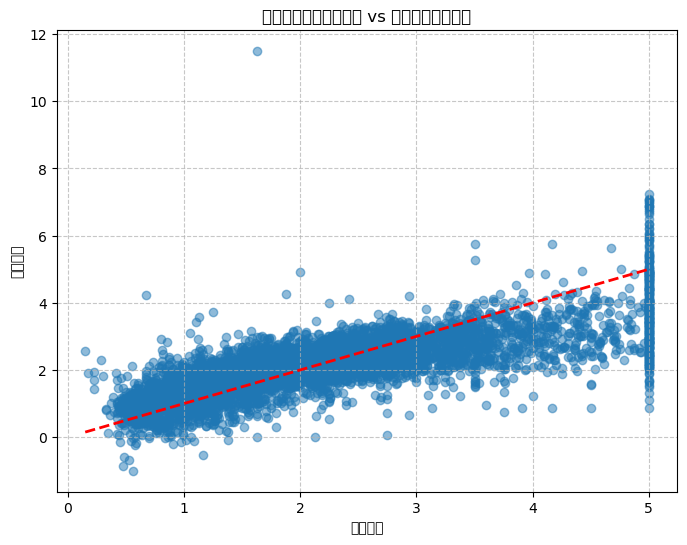

/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 31995 (\N{CJK UNIFIED IDEOGRAPH-7CFB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 32477 (\N{CJK UNIFIED IDEOGRAPH-7EDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_50732/1918612179.py:23: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAP

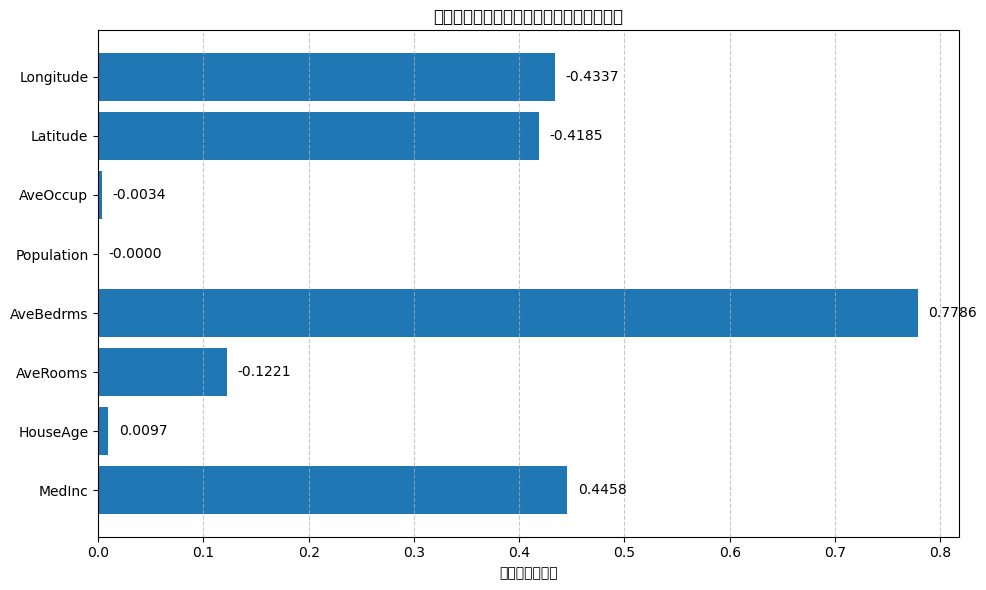

In [6]:
# 可视化：真实值 vs 预测值 (测试集)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # 绘制理想对角线
plt.xlabel('真实房价')
plt.ylabel('预测房价')
plt.title('多元线性回归：真实值 vs 预测值（测试集）')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 可视化：特征重要性（通过系数绝对值大小近似表示）
features = X.columns
coefs = model.coef_
plt.figure(figsize=(10, 6))
bars = plt.barh(features, np.abs(coefs)) # 使用绝对值比较影响大小
plt.xlabel('回归系数绝对值')
plt.title('特征对房价的影响大小（基于系数绝对值）')
# 为条形图添加数值标签
for bar, coef in zip(bars, coefs):
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f'{coef:.4f}', va='center')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

手动训练？

In [4]:
X_train = X_train.to_numpy()
y_train = y_train.to_numpy().reshape(-1)

In [7]:
ws = np.random.randn(8, 1) * 0.01
b = np.zeros(1)

# 标准化（关键）
X_train = (X_train - X_train.mean(axis=0)) / (X_train.std(axis=0) + 1e-8)

learning_rate = 0.01
n_iterations = 1000

def model_pred(x):
    return (x @ ws + b).reshape(-1)

for i in range(n_iterations):
    y_pred = model_pred(X_train)
    batch = len(X_train)

    error = (y_pred - y_train).reshape(-1, 1)

    dw = (2 / batch) * (X_train.T @ error)
    db = (2 / batch) * np.sum(error)

    # 防爆（可选但很有用）
    # dw = np.clip(dw, -10, 10)
    # db = np.clip(db, -10, 10)

    ws -= learning_rate * dw
    b  -= learning_rate * db

    if i % 100 == 0:
        loss = np.mean((y_pred - y_train) ** 2)
        print(f"iter {i}, loss {loss:.4f}")

iter 0, loss 5.6356
iter 100, loss 0.7172
iter 200, loss 0.6017
iter 300, loss 0.5795
iter 400, loss 0.5646
iter 500, loss 0.5537
iter 600, loss 0.5458
iter 700, loss 0.5399
iter 800, loss 0.5356
iter 900, loss 0.5325
